<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-49-random-forest-intuition-code?scriptVersionId=350593168" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🌲 ML 49 — Random Forest | Intuition & Code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, BaggingClassifier

from sklearn.datasets import make_classification, make_circles

In [2]:
X, y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])

df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.489901,-0.355788,-1.337855,0.975307,0.056898,0
1,2.589020,-0.912980,1.994106,1.159321,-1.170982,1
2,-0.858360,0.941034,2.932215,1.849744,-1.564195,1
3,0.778225,-0.743287,-1.403400,1.521261,0.026453,0
4,-0.119439,0.694348,0.494157,-1.144140,-3.025545,1


In [4]:
# function for row sampling

def sample_rows(df, percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [5]:
# function for feature sampling

def sample_features(df, percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [6]:
# function for combined sampling

def combined_sampling(df, row_percent, col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [7]:
df1 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_16/1014091696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [8]:
df2 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_16/1014091696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [9]:
df3 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_16/1014091696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [10]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col2', 'col3', 'target'], dtype='object')
Index(['col3', 'col1', 'target'], dtype='object')
Index(['col3', 'col2', 'target'], dtype='object')


In [11]:
clf1 = DecisionTreeClassifier(random_state=42)
clf2 = DecisionTreeClassifier(random_state=42)
clf3 = DecisionTreeClassifier(random_state=42)

In [12]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier(random_state=42)

[Text(0.5454545454545454, 0.9166666666666666, 'x[0] <= -0.355\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.36363636363636365, 0.75, 'x[1] <= 1.494\ngini = 0.311\nsamples = 26\nvalue = [21, 5]'),
 Text(0.45454545454545453, 0.8333333333333333, 'True  '),
 Text(0.2727272727272727, 0.5833333333333334, 'x[0] <= -1.59\ngini = 0.087\nsamples = 22\nvalue = [21, 1]'),
 Text(0.18181818181818182, 0.4166666666666667, 'x[0] <= -1.813\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.09090909090909091, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.2727272727272727, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.36363636363636365, 0.4166666666666667, 'gini = 0.0\nsamples = 19\nvalue = [19, 0]'),
 Text(0.45454545454545453, 0.5833333333333334, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.7272727272727273, 0.75, 'x[0] <= 0.423\ngini = 0.219\nsamples = 24\nvalue = [3, 21]'),
 Text(0.6363636363636364, 0.8333333333333333, '  False'),
 Text(0.6363636363636364, 0

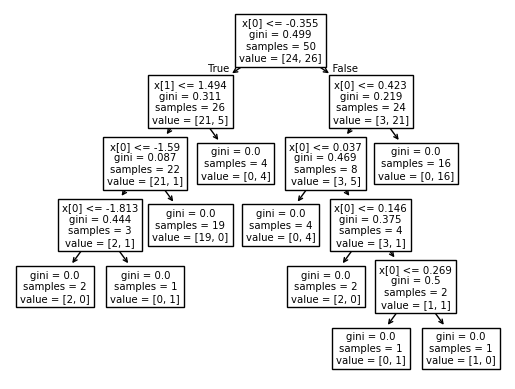

In [13]:
from sklearn.tree import plot_tree

plot_tree(clf1)

[Text(0.6428571428571429, 0.9285714285714286, 'x[0] <= 0.728\ngini = 0.493\nsamples = 50\nvalue = [22.0, 28.0]'),
 Text(0.5, 0.7857142857142857, 'x[1] <= 1.282\ngini = 0.437\nsamples = 31\nvalue = [21, 10]'),
 Text(0.5714285714285714, 0.8571428571428572, 'True  '),
 Text(0.42857142857142855, 0.6428571428571429, 'x[0] <= -0.735\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.2857142857142857, 0.5, 'x[1] <= 1.169\ngini = 0.375\nsamples = 12\nvalue = [9, 3]'),
 Text(0.21428571428571427, 0.35714285714285715, 'x[1] <= 0.078\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.14285714285714285, 0.21428571428571427, 'x[1] <= -0.016\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.07142857142857142, 0.07142857142857142, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.21428571428571427, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2857142857142857, 0.21428571428571427, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.35714285714285715, 0.35714285

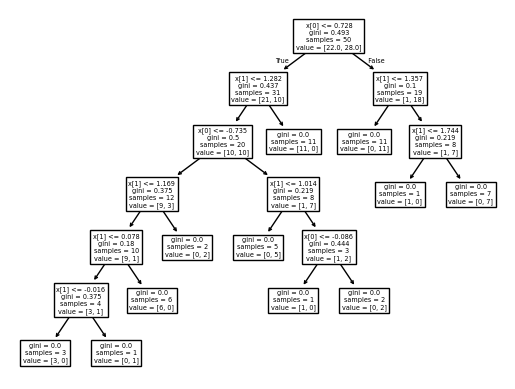

In [14]:
plot_tree(clf2)

[Text(0.5, 0.9, 'x[0] <= -0.289\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.25, 0.7, 'x[1] <= 0.405\ngini = 0.142\nsamples = 26\nvalue = [24, 2]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'gini = 0.0\nsamples = 24\nvalue = [24, 0]'),
 Text(0.375, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.75, 0.7, 'x[1] <= 0.349\ngini = 0.278\nsamples = 24\nvalue = [4, 20]'),
 Text(0.625, 0.8, '  False'),
 Text(0.625, 0.5, 'x[0] <= 0.591\ngini = 0.444\nsamples = 12\nvalue = [4, 8]'),
 Text(0.5, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.75, 0.3, 'x[1] <= 0.037\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.625, 0.1, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.875, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.875, 0.5, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]')]

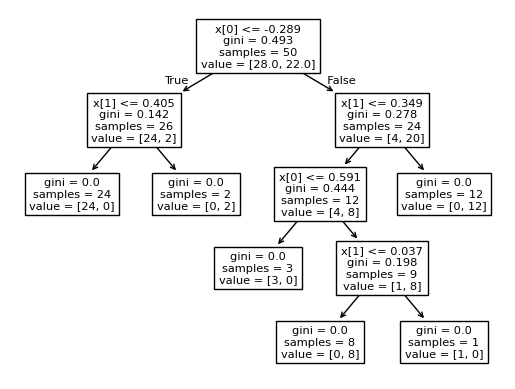

In [15]:
plot_tree(clf3)

In [16]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [17]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [18]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

# Random Forest Demo

In [19]:
np.random.seed(42)

X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

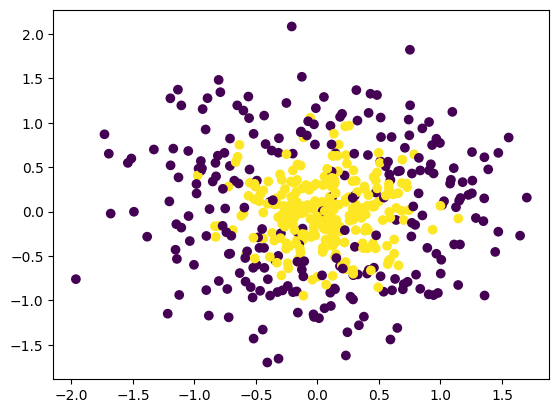

In [20]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

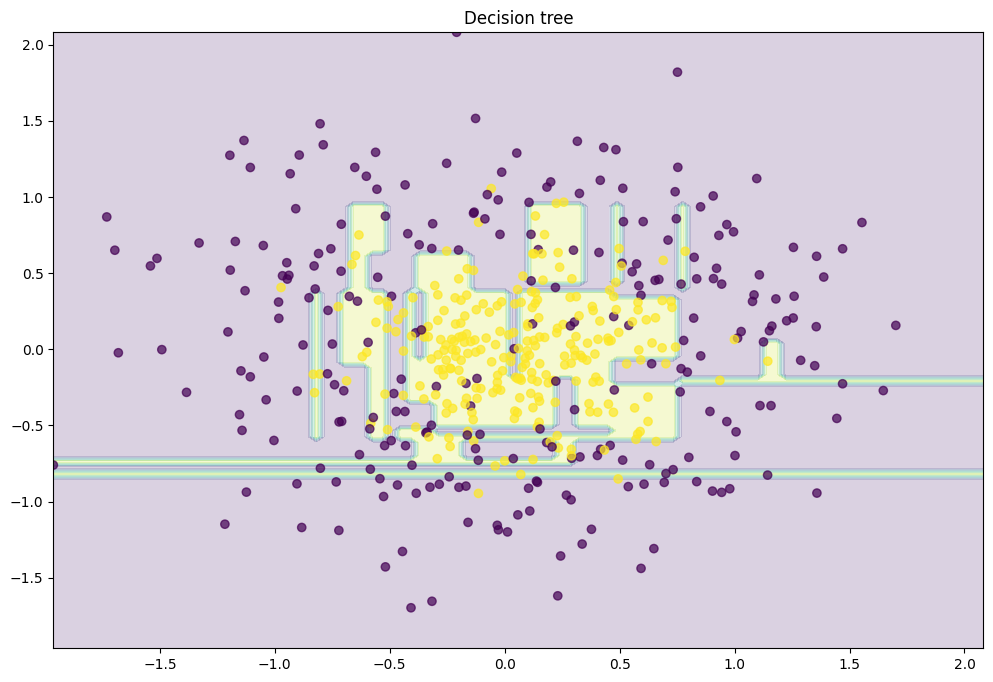

In [21]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Decision tree")
plt.show()

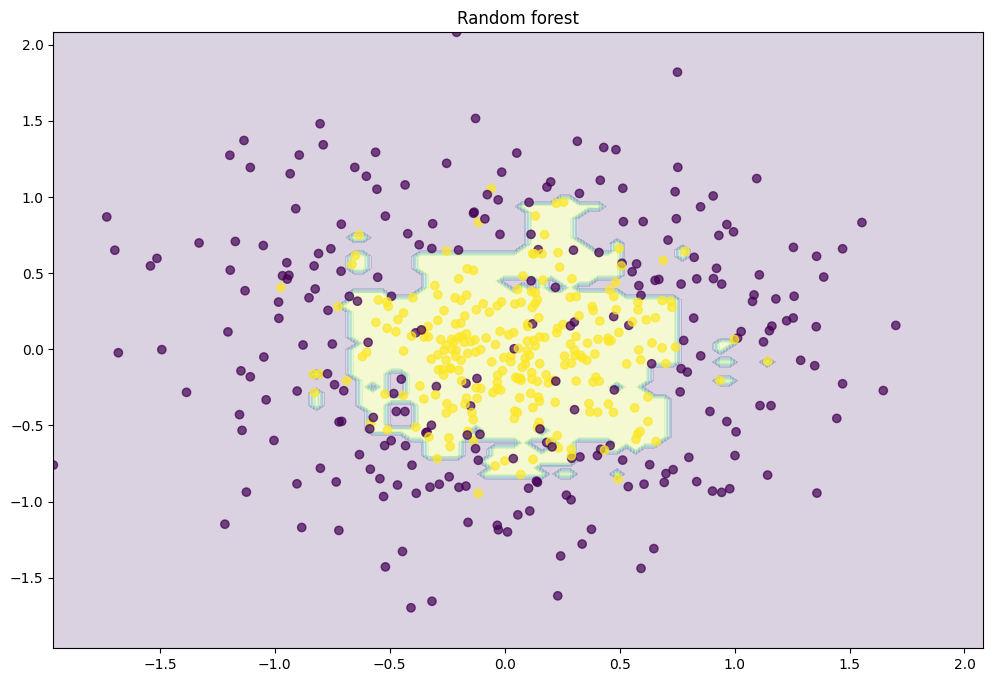

In [22]:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Random forest")
plt.show()

In [23]:
n_train = 150        
n_test = 1000       
noise = 0.1

# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y

In [24]:
X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

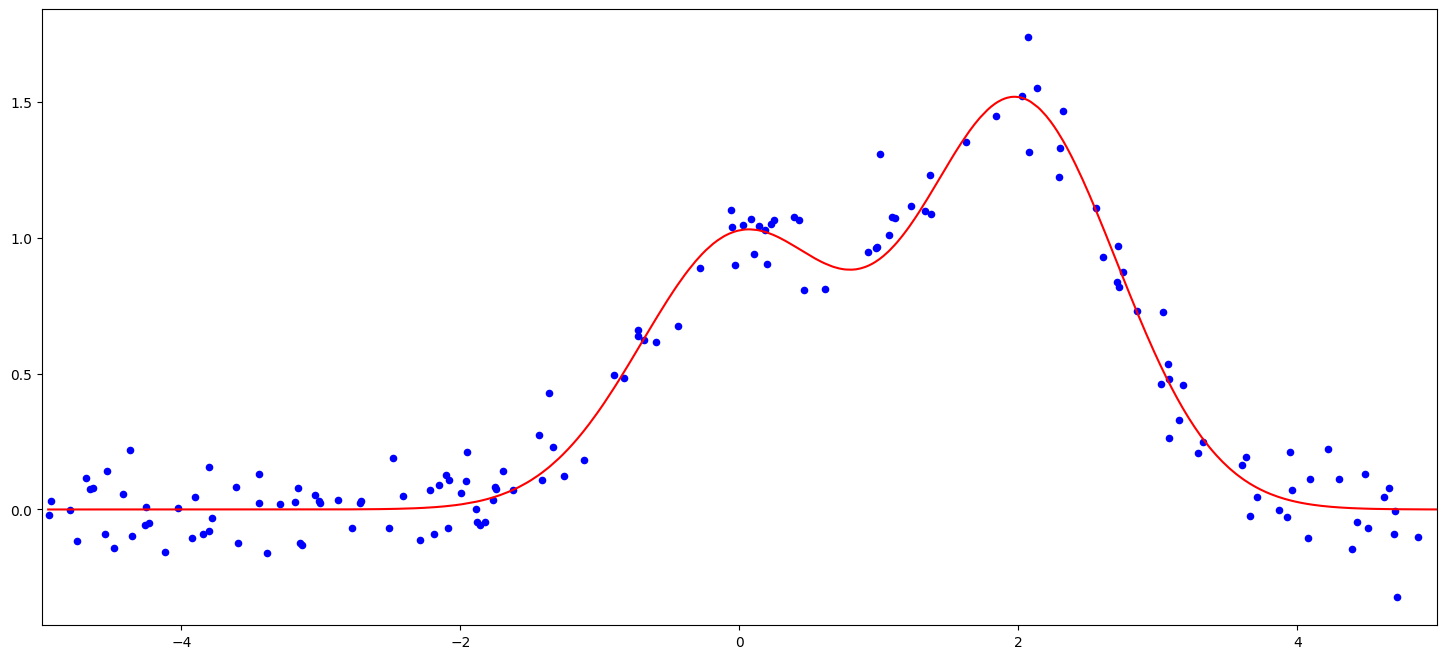

In [25]:
plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.xlim([-5, 5])
plt.show()

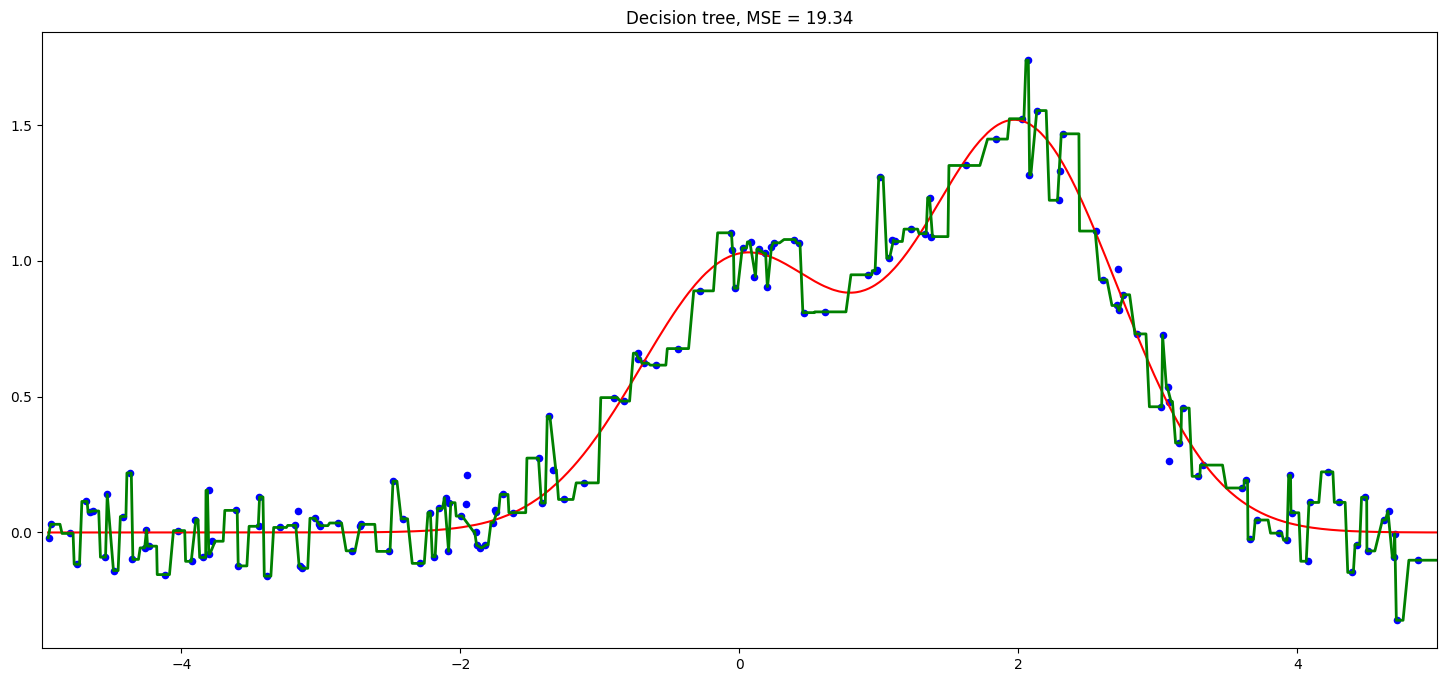

In [26]:
dtree = DecisionTreeRegressor().fit(X_train, y_train)
d_predict = dtree.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f" 
          % np.sum((y_test - d_predict) ** 2))
plt.show()

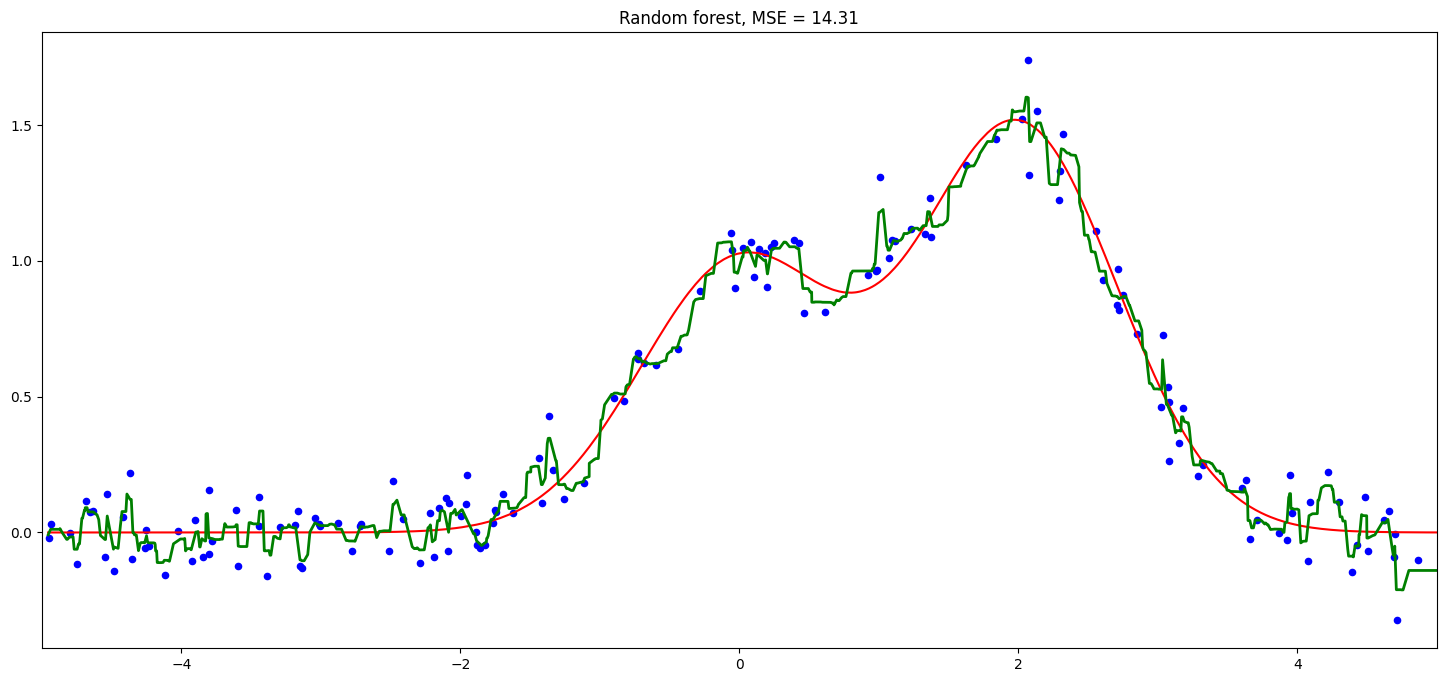

In [27]:
rfr = RandomForestRegressor(n_estimators=1000).fit(X_train, y_train)
rf_predict = rfr.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2))
plt.show()

# Bagging Vs Random Forest

* Bagging -> Tree Based ...
* Random Forest -> Node Based ...

In [28]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [29]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.524379,-0.239080,0.304957,0.267119,-0.889149,0
1,0.818277,-2.156742,0.246023,0.111282,-0.710882,1
2,0.677754,-1.778875,-1.273572,2.080113,2.538501,0
3,1.190280,-2.725063,1.159571,-1.587152,-0.978871,0
4,-0.319797,-2.323768,-0.476165,-1.553751,0.377498,1


In [30]:
bag = BaggingClassifier(max_features=2)

bag.fit(df.iloc[:,:5],df.iloc[:,-1])

BaggingClassifier(max_features=2)

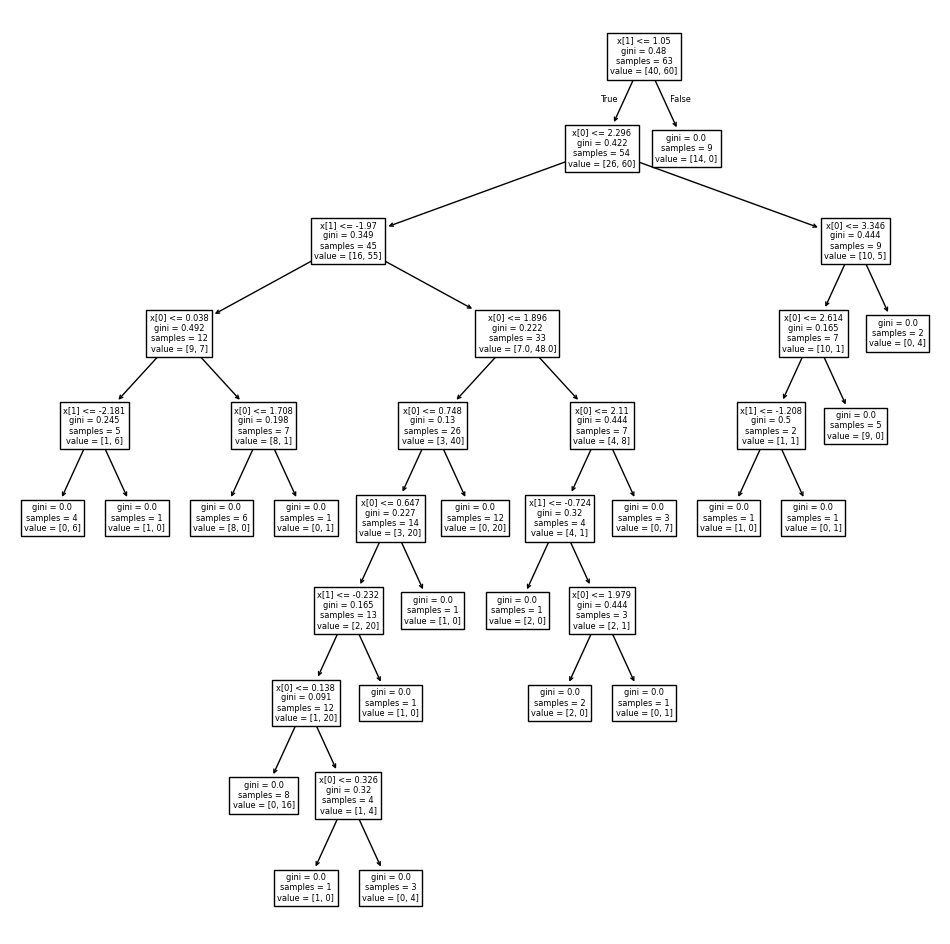

In [31]:
plt.figure(figsize=(12,12))
plot_tree(bag.estimators_[0])
plt.show()

In [32]:
rf = RandomForestClassifier(max_features=2)

rf.fit(df.iloc[:,:5],df.iloc[:,-1])

RandomForestClassifier(max_features=2)

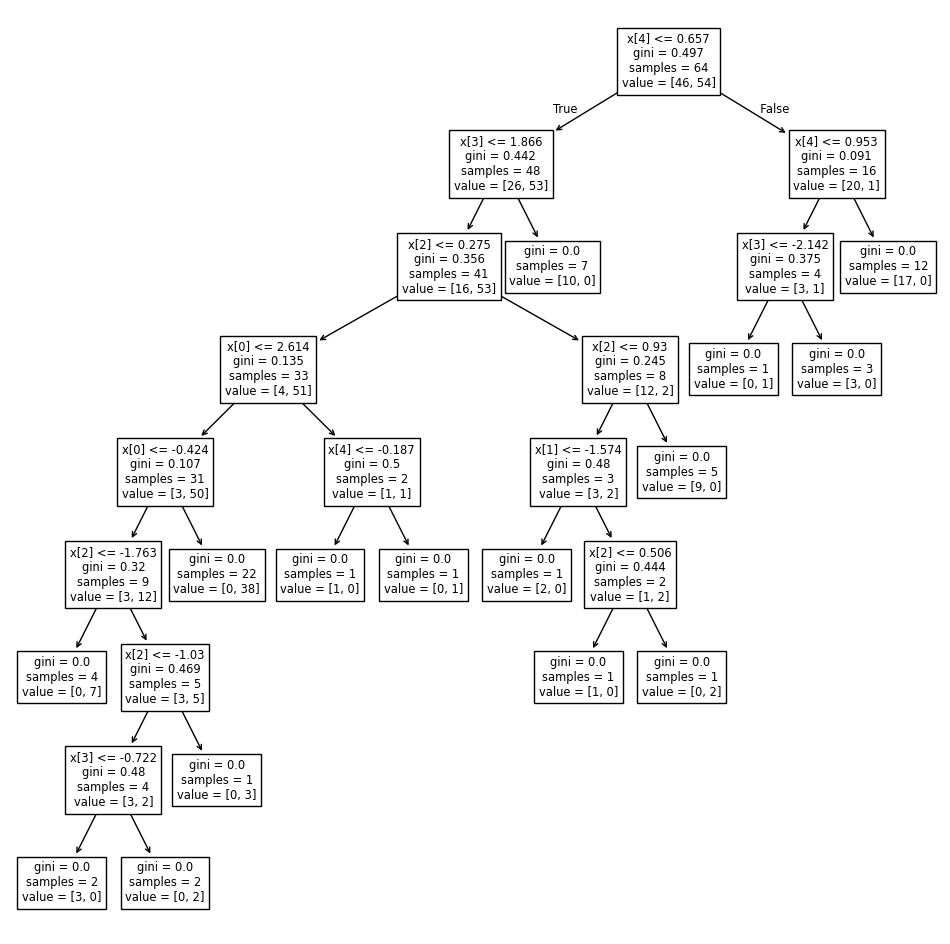

In [33]:
plt.figure(figsize=(12,12))
plot_tree(rf.estimators_[4])
plt.show()